# Probability – Practical

We'll simulate probability experiments, work with `scipy.stats` distributions, and visualise the Central Limit Theorem.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')
np.random.seed(42)

## 1. Simulating Basic Probability

### Law of Large Numbers — Coin Flip

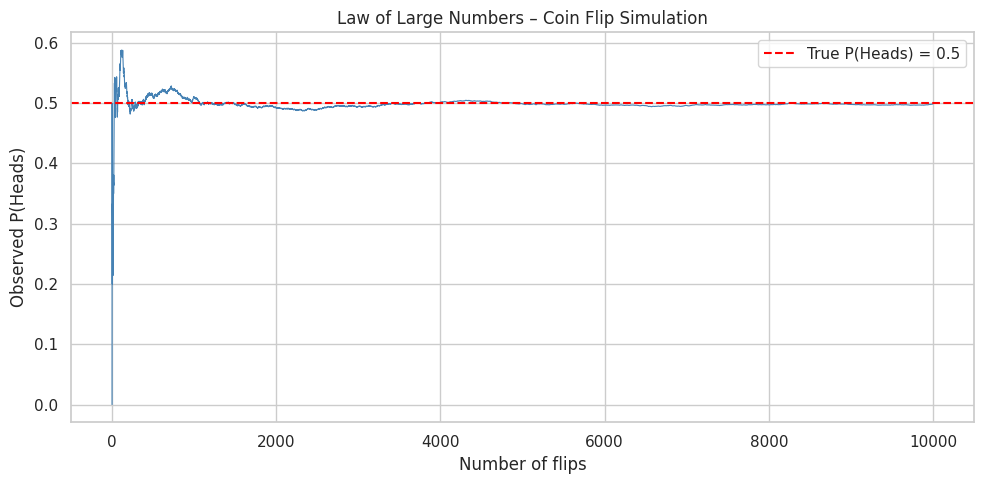

After 10000 flips, observed P(Heads) = 0.4987


In [2]:
# Simulate flipping a fair coin n times; track running probability of heads
n = 10_000
flips = np.random.randint(0, 2, size=n)  # 0=tails, 1=heads

running_prob = np.cumsum(flips) / np.arange(1, n + 1)

plt.plot(running_prob, color='steelblue', linewidth=0.8)
plt.axhline(0.5, color='red', linestyle='--', label='True P(Heads) = 0.5')
plt.xlabel('Number of flips')
plt.ylabel('Observed P(Heads)')
plt.title('Law of Large Numbers – Coin Flip Simulation')
plt.legend()
plt.tight_layout()
plt.show()

print(f"After {n} flips, observed P(Heads) = {running_prob[-1]:.4f}")

## 2. Conditional Probability & Bayes' Theorem

### Medical Test Example

- Disease prevalence: P(D) = 0.01 (1 in 100 people have it)
- Test sensitivity: P(+|D) = 0.99 (true positive rate)
- Test specificity: P(−|D̄) = 0.99 → P(+|D̄) = 0.01 (false positive rate)

What is P(D|+)? — probability of having the disease given a positive test?

In [3]:
p_disease     = 0.01   # prior
p_pos_given_d = 0.99   # sensitivity (likelihood)
p_pos_given_nd = 0.01  # false positive rate

# Bayes' theorem: P(D|+) = P(+|D)*P(D) / P(+)
p_no_disease = 1 - p_disease
p_positive   = p_pos_given_d * p_disease + p_pos_given_nd * p_no_disease  # total probability

p_disease_given_pos = (p_pos_given_d * p_disease) / p_positive

print(f"P(Disease | Positive test) = {p_disease_given_pos:.4f} ({p_disease_given_pos*100:.1f}%)")
print()
print("Despite 99% accuracy, only ~50% chance of actually having the disease!")
print("This is the base-rate fallacy — rare events produce many false positives.")

P(Disease | Positive test) = 0.5000 (50.0%)

Despite 99% accuracy, only ~50% chance of actually having the disease!
This is the base-rate fallacy — rare events produce many false positives.


### From-Scratch: Verifying Bayes' Theorem With a Monte Carlo Simulation

Instead of trusting the algebra, actually simulate 5,000,000 people with the disease's true
prevalence and the test's sensitivity/specificity, then measure the fraction of *positive-tested*
people who actually have the disease — and compare that empirical fraction to the value Bayes'
theorem predicts.

In [4]:
rng = np.random.default_rng(0)
n_people = 5_000_000
sensitivity = 0.99   # P(+ | disease)
specificity = 0.99   # P(- | no disease)

disease = rng.random(n_people) < p_disease
test_pos = np.where(
    disease,
    rng.random(n_people) < sensitivity,
    rng.random(n_people) < (1 - specificity),
)

n_pos = test_pos.sum()
empirical_posterior = disease[test_pos].mean()

print(f"simulated people:                 {n_people}")
print(f"positive tests observed:          {n_pos}")
print(f"Monte Carlo  P(disease | +test):  {empirical_posterior:.4f}")
print(f"Bayes formula P(disease | +test): {p_disease_given_pos:.4f}")
print(f"absolute difference:              {abs(empirical_posterior - p_disease_given_pos):.5f}")

simulated people:                 5000000
positive tests observed:          98854
Monte Carlo  P(disease | +test):  0.4991
Bayes formula P(disease | +test): 0.5000
absolute difference:              0.00087


## 3. Discrete Distributions

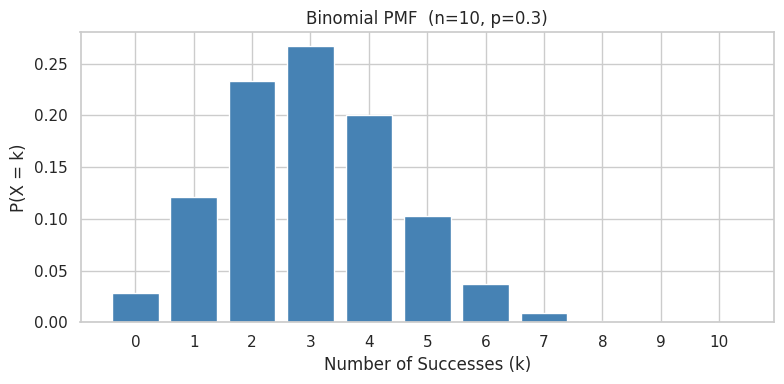

Mean: 3.00  |  Std Dev: 1.45


In [5]:
# Binomial: probability of k successes in n=10 trials with p=0.3
n, p = 10, 0.3
binom = stats.binom(n=n, p=p)

k_values = np.arange(0, n + 1)
pmf = binom.pmf(k_values)

plt.figure(figsize=(8, 4))
plt.bar(k_values, pmf, color='steelblue', edgecolor='white')
plt.xlabel('Number of Successes (k)')
plt.ylabel('P(X = k)')
plt.title(f'Binomial PMF  (n={n}, p={p})')
plt.xticks(k_values)
plt.tight_layout()
plt.show()

print(f"Mean: {binom.mean():.2f}  |  Std Dev: {binom.std():.2f}")

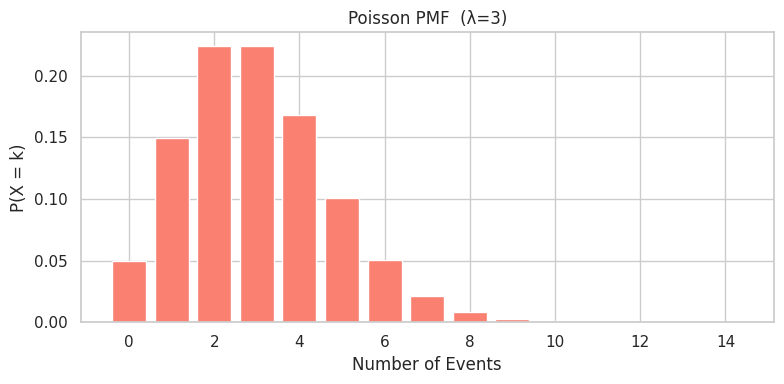

In [6]:
# Poisson: average 3 events per hour (λ=3)
lam = 3
poisson = stats.poisson(mu=lam)
k_vals = np.arange(0, 15)

plt.figure(figsize=(8, 4))
plt.bar(k_vals, poisson.pmf(k_vals), color='salmon', edgecolor='white')
plt.xlabel('Number of Events')
plt.ylabel('P(X = k)')
plt.title(f'Poisson PMF  (λ={lam})')
plt.tight_layout()
plt.show()

## 4. Continuous Distributions

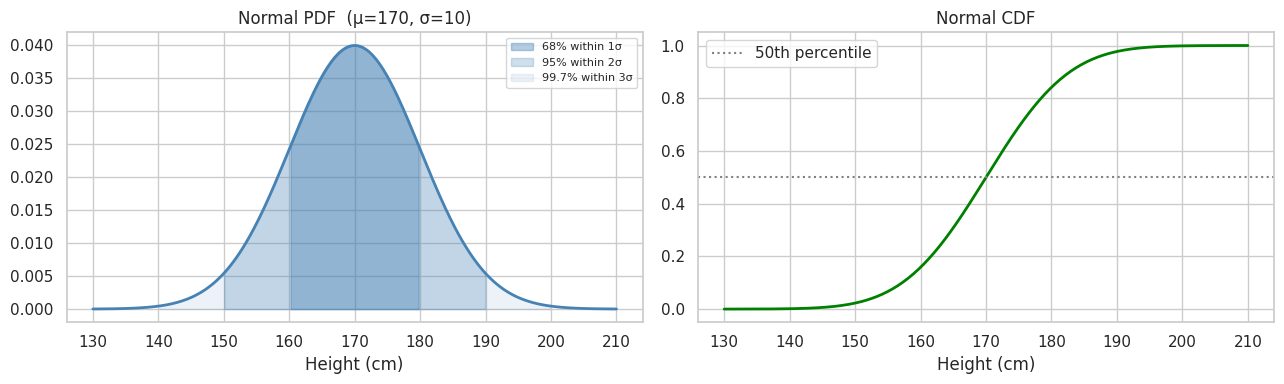

In [7]:
# Normal distribution: plot PDF and CDF
mu, sigma = 170, 10  # e.g., heights in cm
normal = stats.norm(loc=mu, scale=sigma)
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# PDF
ax1.plot(x, normal.pdf(x), color='steelblue', linewidth=2)
# shade ±1σ, ±2σ, ±3σ regions
for z, alpha, label in [(1, 0.4, '68%'), (2, 0.25, '95%'), (3, 0.1, '99.7%')]:
    ax1.fill_between(x, normal.pdf(x),
                     where=(x >= mu - z*sigma) & (x <= mu + z*sigma),
                     alpha=alpha, color='steelblue', label=f'{label} within {z}σ')
ax1.set_title(f'Normal PDF  (μ={mu}, σ={sigma})')
ax1.legend(fontsize=8)
ax1.set_xlabel('Height (cm)')

# CDF
ax2.plot(x, normal.cdf(x), color='green', linewidth=2)
ax2.axhline(0.5, color='gray', linestyle=':', label='50th percentile')
ax2.set_title('Normal CDF')
ax2.set_xlabel('Height (cm)')
ax2.legend()

plt.tight_layout()
plt.show()

In [8]:
# P(height between 160 and 180 cm)
prob = normal.cdf(180) - normal.cdf(160)
print(f"P(160 ≤ height ≤ 180) = {prob:.4f} ({prob*100:.1f}%)")

# z-score of a person who is 185 cm tall
z = (185 - mu) / sigma
print(f"z-score for 185cm = {z:.2f}  →  taller than {normal.cdf(185)*100:.1f}% of people")

P(160 ≤ height ≤ 180) = 0.6827 (68.3%)
z-score for 185cm = 1.50  →  taller than 93.3% of people


## 5. Central Limit Theorem (CLT)

We'll take samples from a **uniform distribution** (clearly non-normal) and watch the distribution of sample means become normal.

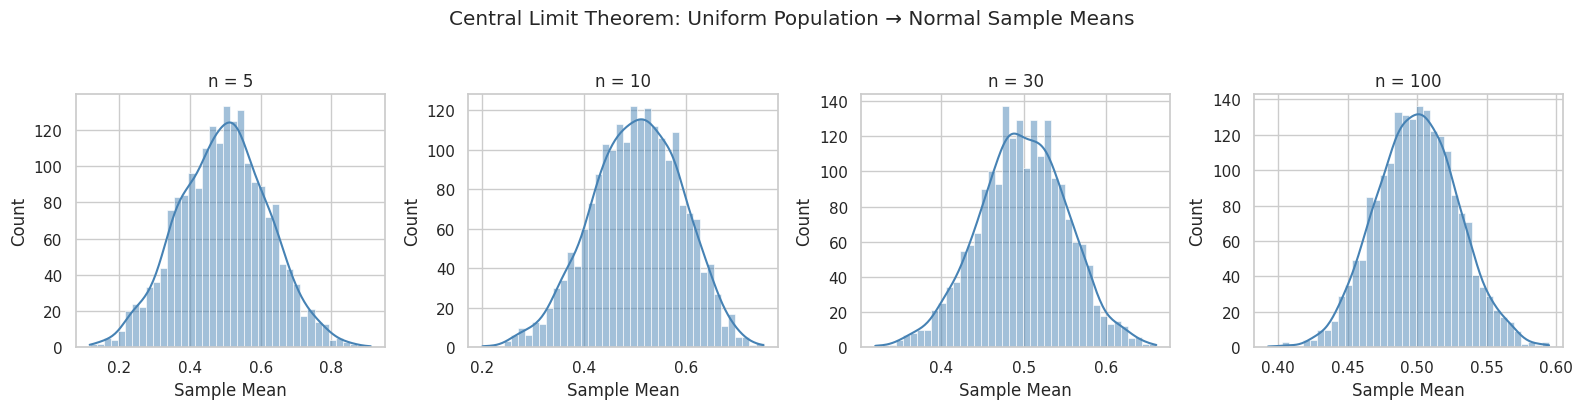

In [9]:
# Population: uniform distribution [0, 1]
population = np.random.uniform(0, 1, size=100_000)

sample_sizes = [5, 10, 30, 100]
n_samples = 2000

fig, axes = plt.subplots(1, len(sample_sizes), figsize=(16, 4))

for ax, n in zip(axes, sample_sizes):
    # Draw n_samples, each of size n; compute mean of each
    sample_means = [np.mean(np.random.choice(population, size=n)) for _ in range(n_samples)]
    sns.histplot(sample_means, bins=40, kde=True, ax=ax, color='steelblue')
    ax.set_title(f'n = {n}')
    ax.set_xlabel('Sample Mean')

plt.suptitle('Central Limit Theorem: Uniform Population → Normal Sample Means', y=1.02)
plt.tight_layout()
plt.show()

## 6. Multiple Distributions — Side-by-Side Comparison

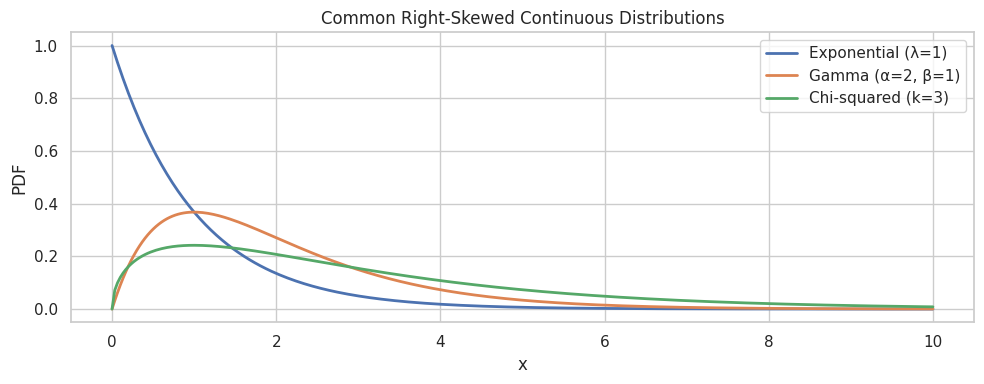

In [10]:
x = np.linspace(0, 10, 300)

distributions = {
    'Exponential (λ=1)': stats.expon(scale=1).pdf(x),
    'Gamma (α=2, β=1)':  stats.gamma(a=2, scale=1).pdf(x),
    'Chi-squared (k=3)': stats.chi2(df=3).pdf(x),
}

plt.figure(figsize=(10, 4))
for name, pdf in distributions.items():
    plt.plot(x, pdf, linewidth=2, label=name)
plt.legend()
plt.title('Common Right-Skewed Continuous Distributions')
plt.xlabel('x')
plt.ylabel('PDF')
plt.tight_layout()
plt.show()